In [1]:
import pandas as pd
import numpy as np
from functools import reduce

IMPORT_OR_EXPORT = "GVA"

if IMPORT_OR_EXPORT == "IMPORT":
    IMGR_OR_EXGR = "IMGR"
elif IMPORT_OR_EXPORT == "EXPORT":
    IMGR_OR_EXGR = "EXGR"
elif IMPORT_OR_EXPORT == "GVA":
    IMGR_OR_EXGR = "GVA"
else:
    print("INVALID!") 

START_YEAR = 2014
END_YEAR   = 2022

In [2]:
# Pre-processing AAMNE : 2014 - 2022

aamne_df = pd.read_csv("./input/AAMNE.csv")
aamne_df = aamne_df[aamne_df["year"].isin(range(START_YEAR,END_YEAR+1))]

#aamne_df = aamne_df[aamne_df["cou"].isin(eps_df["REF_AREA"].unique())]

aamne_df = aamne_df.pivot_table(index=["cou", "year"],
                                  columns=["isic", "own"],
                                  values=IMGR_OR_EXGR,
                                  aggfunc="first")

aamne_df.columns = [f"{industry}_{'Domestic' if own == 'D_MNE' else 'Domestic_OTH' if own == 'D_OTH' else 'Foreign'}"
                    for industry, own in aamne_df.columns]

aamne_df = aamne_df.reset_index().rename(columns={"cou": "REF_AREA", "year": "TIME_PERIOD"})

for column_name in aamne_df.columns:
    if column_name.endswith("OTH"):
        aamne_df = aamne_df.drop(column_name, axis=1)

aamne_df["TIME_PERIOD"] = aamne_df["TIME_PERIOD"].astype(int)

aamne_df.to_excel(f"./output/AAMNE_{IMPORT_OR_EXPORT}.xlsx")

COUNTRY_SET = aamne_df["REF_AREA"].unique()

In [5]:
# Pre-processing EPS : 2014 - 2022 (CHECK FOR UP-TO-DATE)

START_YEAR = 2014
END_YEAR   = 2022
eps_df = pd.read_csv("./input/EPS.csv")
eps_df = eps_df[eps_df["TIME_PERIOD"].isin(range(START_YEAR,END_YEAR+1))]
eps_df = eps_df[eps_df["CLIM_POL"]=="EPS"]
eps_df = eps_df[["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]]

eps_df["TIME_PERIOD"] = eps_df["TIME_PERIOD"].astype(int)
eps_df = eps_df[eps_df["REF_AREA"].isin(COUNTRY_SET)]
eps_df = eps_df.rename(columns={"OBS_VALUE": "EPS"})

eps_df.to_excel("./output/EPS.xlsx")

eps_df["TIME_PERIOD"].unique()

array([2018, 2019, 2020, 2016, 2017, 2014, 2015])

In [6]:
# Pre-processing EPI : 2014 - 2023 (FIXED)
START_YEAR = 2014
END_YEAR   = 2022

INDICATORS = ["BCA", "CDA", "CHA",
              "FGA", "GHO", "GTI",
              "GTP", "LUF", "NDA"]

INDICATOR_WEIGHTS = {"BCA": 0.03, "CDA": 0.33, "CHA": 0.08,
                     "FGA": 0.06, "GHO": 0.05, "GTI": 0.2,
                     "GTP": 0.20, "LUF": 0.02, "NDA": 0.03}

FILEPATHS = [f"./input/EPI/{indicator}_ind_na.csv" for indicator in INDICATORS]

epi_df = pd.DataFrame()

for idx, path in enumerate(FILEPATHS):
    indicator_name = INDICATORS[idx]
    df = pd.read_csv(path)
    df = df.melt(id_vars="iso",
                 value_vars=[f"{indicator_name}.ind.{year}" for year in range(START_YEAR, END_YEAR+1)],
                 var_name="TIME_PERIOD",
                 value_name=f"{indicator_name}_VALUE").rename(columns={"iso": "REF_AREA"})
    if idx == 0:
        epi_df = df
    else:
        epi_df = pd.concat([epi_df, df], axis=1)

epi_df:pd.DataFrame = epi_df.loc[:,~epi_df.columns.duplicated()].copy() # MAGIC
epi_df["EPI"] = 0 

#epi_df.fillna(0.0, inplace=True)
epi_df = epi_df.dropna()

for indicator_name, weight in INDICATOR_WEIGHTS.items():
    epi_df["EPI"] += epi_df[f"{indicator_name}_VALUE"] * weight
    epi_df = epi_df.drop(f"{indicator_name}_VALUE", axis=1)

epi_df["TIME_PERIOD"] = epi_df["TIME_PERIOD"].str.split(".").str[-1].astype(int)
epi_df = epi_df[epi_df["REF_AREA"].isin(COUNTRY_SET)]

epi_df.to_excel("./output/EPI.xlsx")
epi_df.to_csv("./output/EPI.csv")

    REF_AREA     GROUP
4        AGO  Non-OECD
7        ARG  Non-OECD
15       BGD  Non-OECD
29       BGR  Non-OECD
17       BLR  Non-OECD
..       ...       ...
176      SVK      OECD
177      SVN      OECD
189      SWE      OECD
201      TUR      OECD
209      USA      OECD

[72 rows x 2 columns]


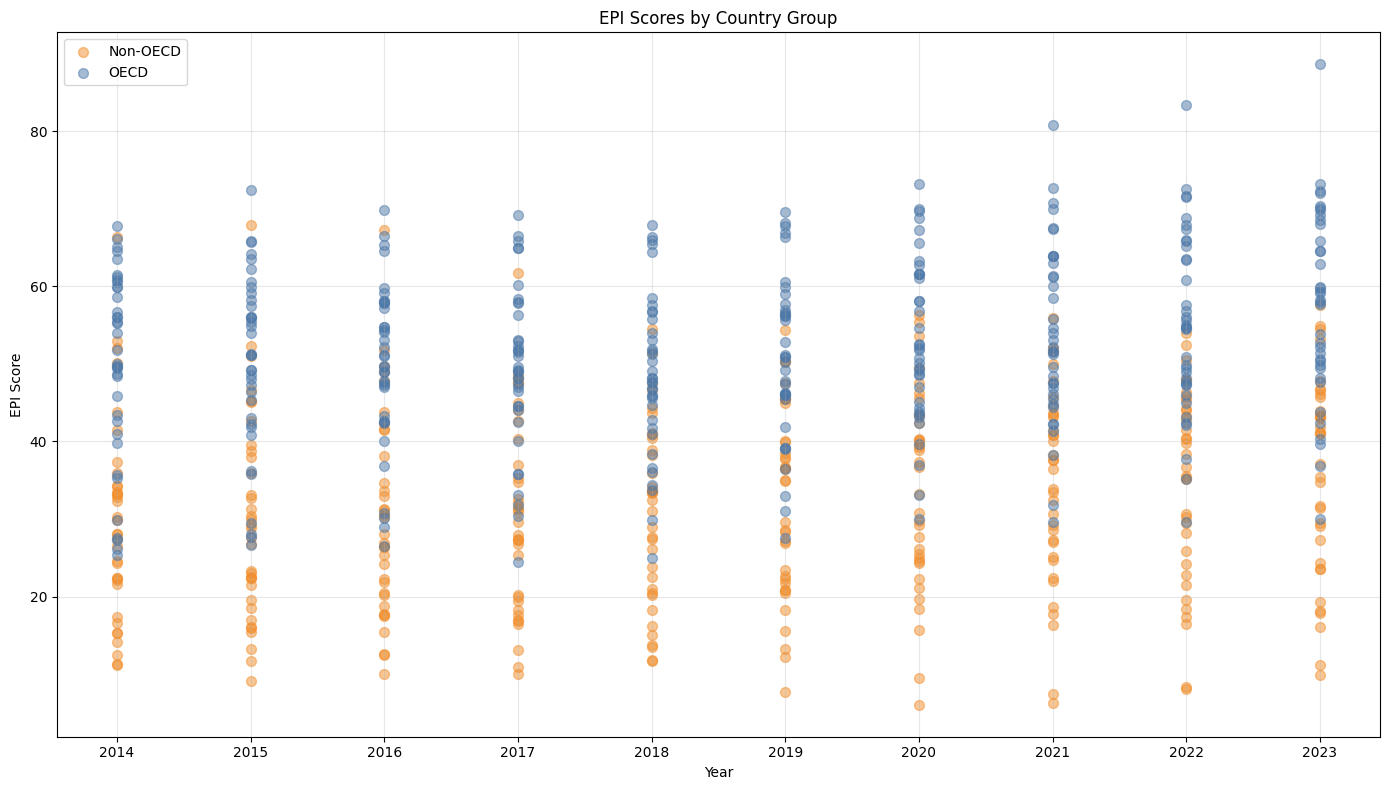

In [16]:
import numpy as np
import matplotlib.pyplot as plt

INDICATORS = ["BCA", "CDA", "CHA",
              "FGA", "GHO", "GTI",
              "GTP", "LUF", "NDA"]

INDICATOR_WEIGHTS = {"BCA": 0.03, "CDA": 0.33, "CHA": 0.08,
                     "FGA": 0.06, "GHO": 0.05, "GTI": 0.2,
                     "GTP": 0.20, "LUF": 0.02, "NDA": 0.03}

FILEPATHS = [f"./input/EPI/{indicator}_ind_na.csv" for indicator in INDICATORS]

epi_df = pd.DataFrame()

for idx, path in enumerate(FILEPATHS):
    indicator_name = INDICATORS[idx]
    df = pd.read_csv(path)
    df = df.melt(id_vars="iso",
                 value_vars=[f"{indicator_name}.ind.{year}" for year in range(2014, 2023+1)],
                 var_name="TIME_PERIOD",
                 value_name=f"{indicator_name}_VALUE").rename(columns={"iso": "REF_AREA"})
    if idx == 0:
        epi_df = df
    else:
        epi_df = pd.concat([epi_df, df], axis=1)

epi_df:pd.DataFrame = epi_df.loc[:,~epi_df.columns.duplicated()].copy() # MAGIC
epi_df["EPI"] = 0 

#epi_df.fillna(0.0, inplace=True)
epi_df = epi_df.dropna()

for indicator_name, weight in INDICATOR_WEIGHTS.items():
    epi_df["EPI"] += epi_df[f"{indicator_name}_VALUE"] * weight
    epi_df = epi_df.drop(f"{indicator_name}_VALUE", axis=1)

epi_df["TIME_PERIOD"] = epi_df["TIME_PERIOD"].str.split(".").str[-1].astype(int)
epi_df = epi_df[epi_df["REF_AREA"].isin(COUNTRY_SET)]

oecd_codes = [
    "AUS", "AUT", "BEL", "CAN", "CHL", "COL", "CRI", "CZE",
    "DNK", "EST", "FIN", "FRA", "DEU", "GRC", "HUN", "ISL",
    "IRL", "ISR", "ITA", "JPN", "LVA", "LTU", "LUX", "MEX",
    "NLD", "NZL", "NOR", "POL", "PRT", "SVK", "SVN", "KOR",
    "ESP", "SWE", "CHE", "TUR", "GBR", "USA"
]

oecd_eu_codes = [
    "AUT", "BEL", "CZE", "DNK", "EST", "FIN", "FRA", "DEU",
    "GRC", "HUN", "IRL", "ITA", "LVA", "LTU", "LUX", "NLD",
    "POL", "PRT", "SVK", "SVN", "ESP", "SWE"
]

epi_df["GROUP"] = np.select(
    [
        #epi_df["REF_AREA"].isin(oecd_eu_codes),
        epi_df["REF_AREA"].isin(oecd_codes)
    ],
    [
        #"EU in OECD",
        "OECD"
    ],
    default="Non-OECD"
)

print(
    epi_df[["REF_AREA", "GROUP"]]
    .drop_duplicates()
    .sort_values(["GROUP", "REF_AREA"])
)

colors = {
    "OECD": "#4C78A8",          # blue
    #"EU in OECD": "#1F4E79",    # darker blue
    "Non-OECD": "#F28E2B"       # orange
}

markers = {
    "OECD": "o",
    #"EU in OECD": "x",
    "Non-OECD": "o"
}

plt.figure(figsize=(14, 8))

for group, group_df in epi_df.groupby("GROUP"):
    plt.scatter(
        group_df["TIME_PERIOD"],
        group_df["EPI"],
        label=group,
        color=colors[group],
        marker=markers[group],
        alpha=0.5,
        s=50
    )

plt.xticks(range(2014, 2023 + 1))
plt.xlabel("Year")
plt.ylabel("EPI Score")
plt.title("EPI Scores by Country Group")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [4]:
# Pre-processing CCPI : 2020 - 2022

START_YEAR = 2020
END_YEAR   = 2022

ccpi_df = pd.read_csv("./input/CCPI.csv")

ccpi_df = ccpi_df.melt(id_vars="ISO",
                       value_vars=[str(year) for year in range(START_YEAR, END_YEAR+1)],
                       var_name="TIME_PERIOD",
                       value_name="CCPI_SCORE").rename(columns={"ISO": "REF_AREA"})

ccpi_df["TIME_PERIOD"] = ccpi_df["TIME_PERIOD"].astype(int)
ccpi_df = ccpi_df[ccpi_df["REF_AREA"].isin(COUNTRY_SET)]

ccpi_df.to_excel("./output/CCPI.xlsx")

ccpi_df["TIME_PERIOD"].unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [7]:
# Pre-processing GDP : 1960 - 2025
START_YEAR = 2014
END_YEAR   = 2022
gdp_df=pd.read_csv("./input/GDP_DATA.csv")

gdp_df = gdp_df.melt("Country Code",
                      [str(year) for year in range(START_YEAR, END_YEAR+1)],
                    "TIME_PERIOD",
                    "GDP").rename(columns = {"Country Code": "REF_AREA"})

gdp_df["TIME_PERIOD"] = gdp_df["TIME_PERIOD"].astype(int)
gdp_df = gdp_df[gdp_df["REF_AREA"].isin(COUNTRY_SET)]

gdp_df.to_excel("./output/GDP.xlsx")

gdp_df["TIME_PERIOD"].unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [8]:
# Pre-processing TRADE : 1960 - 2025
START_YEAR = 2014
END_YEAR   = 2022
trade_df = pd.read_csv("./input/TRADE_OPEN.csv")
trade_df = trade_df.melt("Country Code",
                      [str(year) for year in range(START_YEAR, END_YEAR+1)],
                    "TIME_PERIOD",
                    "TRADE").rename(columns = {"Country Code": "REF_AREA"})

trade_df["TIME_PERIOD"] = trade_df["TIME_PERIOD"].astype(int)
trade_df = trade_df[trade_df["REF_AREA"].isin(COUNTRY_SET)]

trade_df.to_excel("./output/TRADE.xlsx")

trade_df["TIME_PERIOD"].unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [9]:
# Pre-processing INTEREST PAYMENTS : 1960 - 2025
START_YEAR = 2014
END_YEAR   = 2022
interest_df = pd.read_csv("./input/INTEREST_PAYMENTS.csv")

interest_df = interest_df.melt(id_vars="Country Code",
                       value_vars=[str(year) for year in range(START_YEAR, END_YEAR+1)],
                       var_name="TIME_PERIOD",
                       value_name="INTEREST_PAYMENTS").rename(columns={"Country Code": "REF_AREA"})

interest_df["TIME_PERIOD"] = interest_df["TIME_PERIOD"].astype(int)
interest_df = interest_df[interest_df["REF_AREA"].isin(COUNTRY_SET)]

interest_df.to_excel("./output/INTEREST_PAYMENTS.xlsx")

interest_df["TIME_PERIOD"].unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [10]:
# Pre-processing OIL RENTS : 1960 - 2025
START_YEAR = 2014
END_YEAR   = 2022
oil_rents_df = pd.read_csv("./input/OIL_RENTS.csv")

oil_rents_df = oil_rents_df.melt(id_vars="Country Code",
                       value_vars=[str(year) for year in range(START_YEAR, END_YEAR+1)],
                       var_name="TIME_PERIOD",
                       value_name="OIL_RENTS").rename(columns={"Country Code": "REF_AREA"})

oil_rents_df["TIME_PERIOD"] = oil_rents_df["TIME_PERIOD"].astype(int)
oil_rents_df = oil_rents_df[oil_rents_df["REF_AREA"].isin(COUNTRY_SET)]

oil_rents_df.to_excel("./output/OIL_RENTS.xlsx")

oil_rents_df["TIME_PERIOD"].unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [11]:
# Pre-processing FINANCIAL DEVELOPMENT : 1980 - 2020
START_YEAR = 2014
END_YEAR   = 2020
financial_dev_df = pd.read_csv("./input/FINANCIAL_DEVELOPMENT.csv")
financial_dev_df = financial_dev_df[financial_dev_df["INDICATOR"]=="Financial Development Index"]

financial_dev_df["COUNTRY_CODE"] = financial_dev_df["SERIES_CODE"].str[0:3]
financial_dev_df = financial_dev_df[financial_dev_df["COUNTRY_CODE"].isin(aamne_df["REF_AREA"].unique())]

financial_dev_df = financial_dev_df.melt(id_vars="COUNTRY_CODE",
                       value_vars=[str(year) for year in range(START_YEAR, END_YEAR+1)],
                       var_name="TIME_PERIOD",
                       value_name="FINANCIAL_DEVELOPMENT").rename(columns={"COUNTRY_CODE": "REF_AREA"})

financial_dev_df["TIME_PERIOD"] = financial_dev_df["TIME_PERIOD"].astype(int)
financial_dev_df = financial_dev_df[financial_dev_df["REF_AREA"].isin(COUNTRY_SET)]

financial_dev_df.to_excel("./output/FINANCIAL_DEVELOPMENT.xlsx")

financial_dev_df["TIME_PERIOD"].unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020])

In [12]:
# 2. Fill missing keys with placeholders
fill_values = {'REF_AREA': 'UNKNOWN_AREA', 'TIME_PERIOD': 'UNKNOWN_TIME'}
filled_dfs = [df.fillna(fill_values) for df in [eps_df, epi_df, ccpi_df, aamne_df, gdp_df, trade_df, interest_df, oil_rents_df, financial_dev_df]]

# 3. Merge using how='outer' to ensure no rows or unique columns are dropped
final_df = reduce(
    lambda left, right: pd.merge(left, right, on=['REF_AREA', 'TIME_PERIOD'], how='outer'), 
    filled_dfs
)

# 4. Revert placeholders back to NaN
final_df[['REF_AREA', 'TIME_PERIOD']] = final_df[['REF_AREA', 'TIME_PERIOD']].replace({
    'UNKNOWN_AREA': np.nan, 
    'UNKNOWN_TIME': np.nan
})

final_df = final_df.dropna(subset=["EPI"])

final_df.to_excel(f"./output/COMPLETE_{IMPORT_OR_EXPORT}.xlsx")
final_df.to_csv(f"./output/COMPLETE_{IMPORT_OR_EXPORT}.csv")